In [ ]:
%pip install catboost lightgbm xgboost

In [ ]:
%pip install optuna

In [20]:
# from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import pandas as pd

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.models import train_pipline
from src.utils import show_confusion_matrix

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
train_df_FE = pd.read_csv(r'..\data\processed\train_df_FE.csv')
test_df_FE = pd.read_csv(r'..\data\processed\test_df_FE.csv')
orig_df_FE = pd.read_csv(r'..\data\processed\orig_df_FE.csv')
combined_df_FE = pd.read_csv(r'..\data\processed\combined_df_FE.csv')

X = combined_df_FE.drop(['class'],axis=1)
y = combined_df_FE['class']

In [3]:
X

,alpha,delta,u,g,r,i,z,redshift,color_ug,color_gr,...,sky_x,sky_y,sky_z,z_x_u_g,z_x_g_r,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,135.689107,32.494632,23.878820,22.275300,20.395010,19.165730,18.793710,0.634794,1.603520,1.880290,...,-0.603533,0.589187,0.537221,1.017904,1.193596,0,0,1,0,1
1,144.826101,31.274185,24.777590,22.831880,22.584440,21.168120,21.614270,0.779136,1.945710,0.247440,...,-0.698632,0.492354,0.519134,1.515973,0.192789,1,0,0,0,0
2,142.188790,35.582444,25.263070,22.663890,20.609760,19.348570,18.948270,0.644195,2.599180,2.054130,...,-0.642519,0.498590,0.581874,1.674377,1.323259,0,0,1,0,1
3,338.741038,-0.402828,22.136820,23.776560,21.611620,20.504540,19.250100,0.932346,-1.639740,2.164940,...,0.931928,-0.362575,-0.007031,-1.528804,2.018472,0,0,1,0,0
4,345.282593,21.183866,19.437180,17.580280,16.497470,15.977110,15.544610,0.116123,1.856900,1.082810,...,0.901833,-0.236884,0.361362,0.215628,0.125739,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677331,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,1.974528,1.151093,...,-0.724210,-0.688194,0.043684,1.010019,0.588812,0,0,1,0,1
677332,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,1.375570,1.661308,...,-0.545742,-0.525106,0.653015,0.905936,1.094120,0,0,1,0,1
677333,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0.728394,2.189890,...,0.612052,0.790731,0.011726,0.274125,0.824148,0,0,1,0,1
677334,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,0.347115,0.635191,...,-0.243999,-0.585084,0.773396,0.995651,1.821956,0,1,0,0,0


In [4]:
X.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'color_ug',
       'color_gr', 'color_ri', 'color_iz', 'color_ur', 'color_gi', 'color_uz',
       'log1p_redshift', 'redshift_inter_ug', 'redshift_inter_gr',
       'redshift_x_z', 'stellar_locus_dist', 'qso_locus_dist',
       'quasar_color_region', 'mag_mean', 'mag_max', 'mag_min', 'mag_range',
       'alpha_sin', 'alpha_cos', 'delta_sin', 'delta_cos', 'ug_gr', 'gr_ri',
       'ri_iz', 'redshift_sq', 'redshift_low', 'redshift_mid', 'redshift_high',
       'sky_x', 'sky_y', 'sky_z', 'z_x_u_g', 'z_x_g_r', 'spectral_type_A/F',
       'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B',
       'galaxy_population_Red_Sequence'],
      dtype='str')

In [5]:
y

0         0
1         0
2         0
3         0
4         0
         ..
677331    0
677332    0
677333    0
677334    1
677335    1
Name: class, Length: 677336, dtype: int64

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

target_names =['GALAXY', 'QSO', 'STAR']

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [14]:
y_resampled.value_counts()

class
0    436922
1    436922
2    436922
Name: count, dtype: int64

Cross Validating with LGBMClassifier Model Now...
Fold 1: 0.97068
Fold 2: 0.97046
Fold 3: 0.97076
Fold 4: 0.97036
Fold 5: 0.97012
Mean CV Accuracy: 0.97048



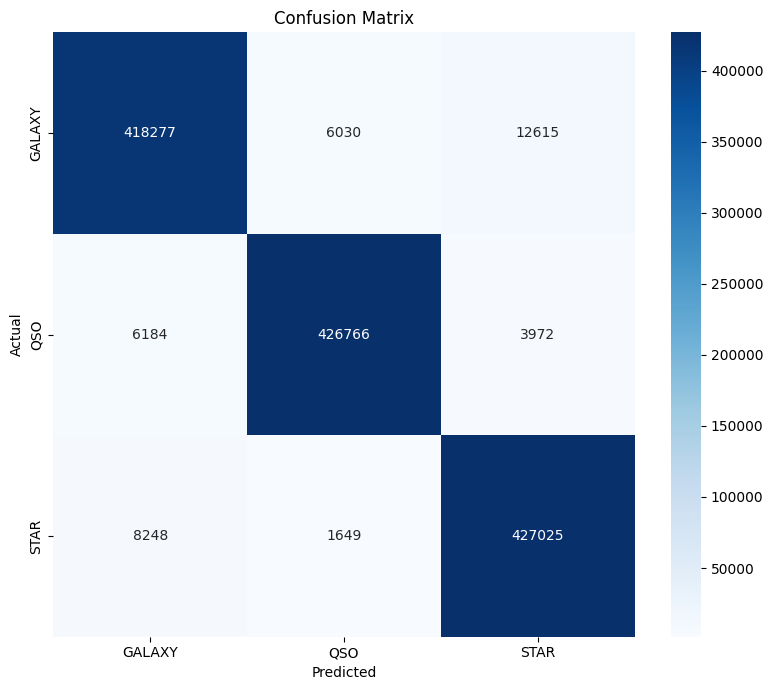

              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.96    436922
         QSO       0.98      0.98      0.98    436922
        STAR       0.96      0.98      0.97    436922

    accuracy                           0.97   1310766
   macro avg       0.97      0.97      0.97   1310766
weighted avg       0.97      0.97      0.97   1310766



In [15]:
LGBM_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,LGBMClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

Cross Validating with XGBClassifier Model Now...
Fold 1: 0.97406
Fold 2: 0.97344
Fold 3: 0.97371
Fold 4: 0.97379
Fold 5: 0.97374
Mean CV Accuracy: 0.97375



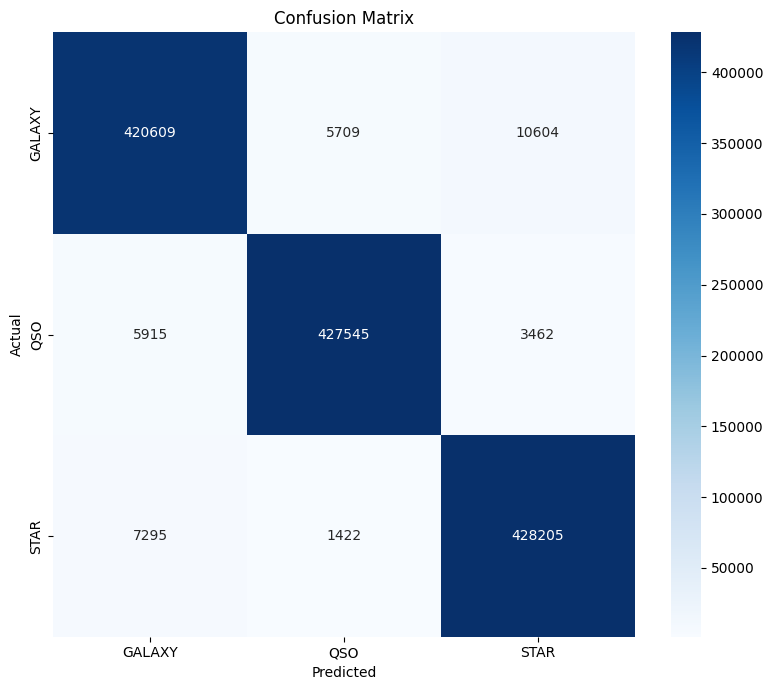

              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.97    436922
         QSO       0.98      0.98      0.98    436922
        STAR       0.97      0.98      0.97    436922

    accuracy                           0.97   1310766
   macro avg       0.97      0.97      0.97   1310766
weighted avg       0.97      0.97      0.97   1310766



In [16]:
XGB_model,y_preds, y_probas = train_pipline(X_resampled,y_resampled,XGBClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

In [17]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': LGBM_model.feature_importances_})

fi.sort_values('importances',ascending=False)

,features,importances
33,redshift_sq,696
29,delta_cos,487
15,log1p_redshift,382
37,sky_x,377
27,alpha_cos,363
1,delta,346
8,color_ug,340
6,z,324
3,g,323
7,redshift,320


In [18]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': XGB_model.feature_importances_})

fi.sort_values('importances',ascending=False)

,features,importances
15,log1p_redshift,0.312635
13,color_gi,0.182910
18,redshift_x_z,0.180518
12,color_ur,0.061721
3,g,0.021275
35,redshift_mid,0.018990
33,redshift_sq,0.017855
17,redshift_inter_gr,0.015580
45,spectral_type_O/B,0.015369
44,spectral_type_M,0.015328
